In [2]:
import numpy as np
import scanpy as sc
from matplotlib import pyplot as plt
import seaborn as sns
import anndata 

In [3]:
np.random.seed(42)

#noise features
noise = np.random.poisson(lam=1,size=(1000,998))

#informative features - cell type A
a1 = np.random.poisson(lam=10,size=(10,1))
a2 = np.random.poisson(lam=1,size=(10,1))

#informative features - cell type B
b1 = np.random.poisson(lam=10,size=(10,1))
b2 = np.random.poisson(lam=1,size=(10,1))

#informative features - cell type C
c1 = np.random.poisson(lam=100,size=(646,1))
c2 = np.random.poisson(lam=1,size=(646,1))

#informative features - cell type D
d1 = np.random.poisson(lam=100,size=(334,1))
d2 = np.random.poisson(lam=50,size=(334,1))

#assemble informative genes
gene1 = np.concatenate([a1,b1,c1,d1])
gene2 = np.concatenate([a2,b2,c2,d2])

print(gene1.size); print(gene2.size)

#assemble all data
X = np.concatenate([gene1,gene2,noise],axis=1)
colors = np.array(['tab:blue']*10 + ['tab:red']*10 + ['tab:grey']*646 + ['tab:green']*334)
labels = np.array(['a']*10 + ['b']*10 + ['c']*646 + ['d']*334)
X.shape

1000
1000


(1000, 1000)

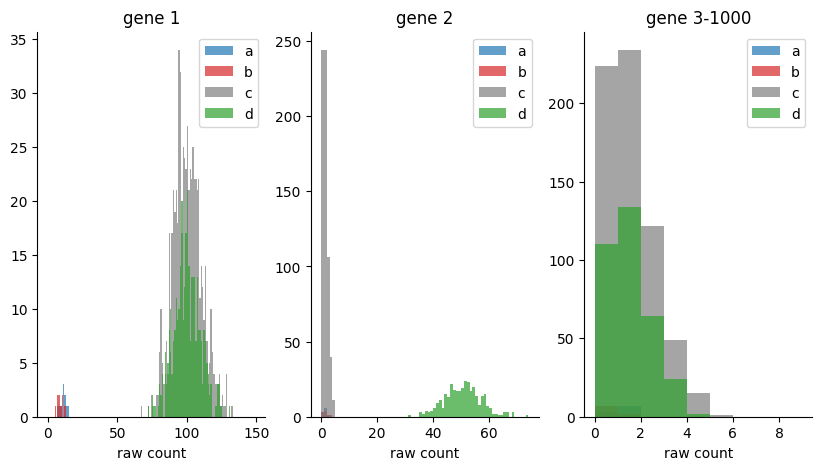

In [4]:
#Show raw data for informative genes
plt.figure(figsize=(10,5))
colors3= ['tab:blue'] + ['tab:red'] + ['tab:grey'] + ['tab:green']
celltypes = ['a','b','c','d']
celltype_Xs = [X[:10,:], X[11:20,:], X[21:666,:], X[666:1000,:]]
for X_type,celltype,color in zip(celltype_Xs,celltypes,colors3):
    plt.subplot(131)
    plt.hist(X_type[:,0],bins=np.arange(0,150),alpha=0.7,label=celltype,color=color)
    plt.xlabel('raw count')
    plt.title('gene 1')
    plt.legend()
    plt.subplot(132)
    plt.hist(X_type[:,1],bins=np.arange(0,75),alpha=0.7,label=celltype,color=color)
    plt.xlabel('raw count')
    plt.title('gene 2')
    plt.legend()
    plt.subplot(133)
    plt.hist(X_type[:,2],bins=np.arange(0,10),alpha=0.7,label=celltype,color=color)
    plt.xlabel('raw count')
    plt.title('gene 3-1000')
    plt.legend()

sns.despine()

In [5]:
adata = anndata.AnnData(X=X,obs=dict(clusterlabels=labels,colors=colors))

#scanpy default normalization as in https://scanpy.readthedocs.io/en/stable/tutorials/basics/clustering.html
adata.layers['scanpy_default'] = sc.pp.log1p(sc.pp.normalize_total(adata,inplace=False)['X'])
adata.obsm['scanpy_default_pca'] = sc.pp.pca(adata.layers['scanpy_default'])

#baseline used in scGBM paper in Fig 4a
adata.layers['log+scale'] = sc.pp.scale(sc.pp.log1p(sc.pp.normalize_total(adata,inplace=False,target_sum=10000)['X']))
adata.obsm['log+scale_pca'] = sc.pp.pca(adata.layers['log+scale'])

#analytic Pearson residuals + PCA
sc.experimental.pp.normalize_pearson_residuals_pca(adata)
adata.obsm['analytic_pearson_residuals_pca']=adata.obsm['X_pca'].copy() #rename APR field

adata

AnnData object with n_obs × n_vars = 1000 × 1000
    obs: 'clusterlabels', 'colors'
    uns: 'pca', 'pearson_residuals_normalization'
    obsm: 'scanpy_default_pca', 'log+scale_pca', 'X_pca', 'analytic_pearson_residuals_pca'
    varm: 'PCs'
    layers: 'scanpy_default', 'log+scale'

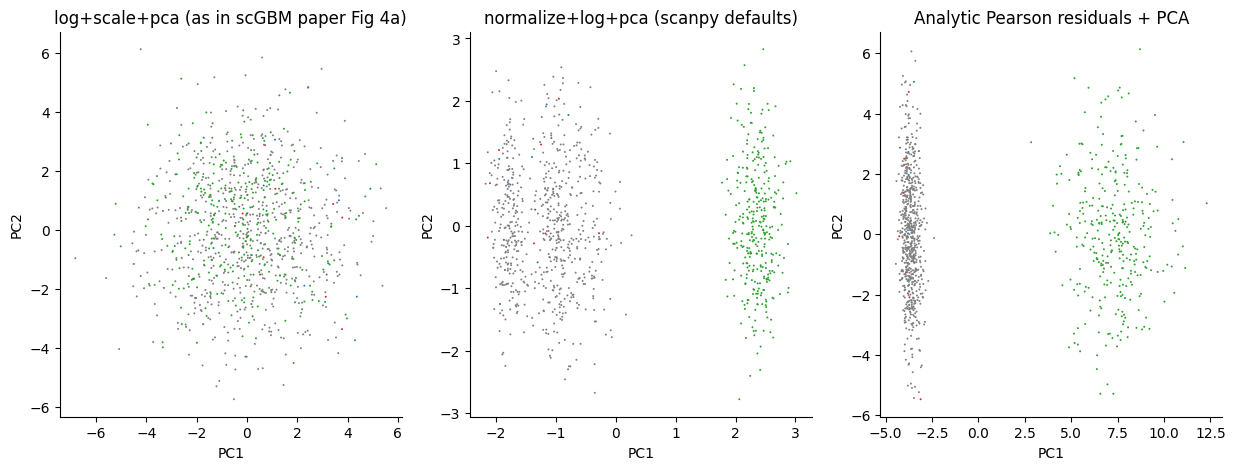

In [6]:
plt.figure(figsize=(15,5))

plt.subplot(1,3,3)

plt.title('Analytic Pearson residuals + PCA')
plt.scatter(*adata.obsm['analytic_pearson_residuals_pca'][:,:2].T,c=colors,lw=0,s=2)
plt.xlabel('PC1')
plt.ylabel('PC2')
sns.despine()

plt.subplot(1,3,2)

plt.title('normalize+log+pca (scanpy defaults)')
plt.scatter(*adata.obsm['scanpy_default_pca'][:,:2].T,c=colors,lw=0,s=2)
plt.xlabel('PC1')
plt.ylabel('PC2')
sns.despine()

plt.subplot(1,3,1)

plt.title('log+scale+pca (as in scGBM paper Fig 4a)')
plt.scatter(*adata.obsm['log+scale_pca'][:,:2].T,c=colors,lw=0,s=2)
plt.xlabel('PC1')
plt.ylabel('PC2')
sns.despine()